# Bjerknes feedback changes over time

## imports

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import copy
import time

# Import custom modules
import src.utils

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## Funcs

In [ ]:
def window(x):
    return src.utils.get_windowed(x, stride=120)


def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom

def regress_over_time(data, x_vars, y_vars, dims=["time", "member"]):
    """regression over time"""

    ## get windowed data
    data_ = window(data)

    ## empty list to hold coefficients
    coefs = []

    ## shared args
    kwargs = dict(x_vars=x_vars, y_vars=y_vars, dims=dims)

    ## loop thru years
    for year in tqdm.tqdm(data_.year):

        ## get grouped data
        data_y = data_.sel(year=year).groupby("time.month")

        ## do regression
        coefs.append(data_y.map(src.utils.regress_xr_proj, **kwargs))

    return xr.concat(coefs, dim=data_.year)


def regress_wrapper(data, x_vars, y_var, y_fn, dims=["time", "member"]):
    """regression over time"""

    ## prep data
    y_data = src.utils.reconstruct_wrapper(data[[f"{y_var}", f"{y_var}_comp"]], fn=y_fn)

    ## subset for data
    data_ = xr.merge([data[x_vars], y_data])

    return regress_over_time(data_, x_vars=x_vars, y_vars=[y_var], dims=dims)


def frac_change(x):
    """fractional change"""
    return x / x.isel(year=0) - 1


def make_scatter_ax(ax, anom_, xvar, yvar, month, label, by_season=True):
    """scatter plot of data for given month"""

    ## prep func
    if by_season:
        get_season = lambda x: src.utils.sel_month(
            x.resample({"time": "QS-JAN"}).mean(), month
        )

    else:
        get_season = lambda x: src.utils.sel_month(x, month)

    prep = lambda x: get_season(x).transpose("time", "member")

    ## get plot data
    plot_data = (prep(anom_[xvar]), prep(anom_[yvar]))

    ## get stats
    corr = xr.corr(*plot_data)
    cov = xr.cov(*plot_data)
    m = cov / plot_data[0].var()

    ## plot data
    ax.scatter(*plot_data, s=3, label=f"m = {m.item():.1e}\nr = {corr.item():.2f}")
    ax.set_title(f"{label}")

    ## formatting
    ax_kwargs = dict(ls="--", c="gray", lw=0.5)
    ax.axvline(0, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.legend(prop=dict(size=10))

    return ax


def make_scatter(anom_, xvar, yvar, month, by_season=True):
    """scatter plot of data for given month"""

    fig, axs = plt.subplots(1, 4, figsize=(11, 2.5), layout="constrained")

    for ax, t_idx, label in zip(
        axs,
        [["1850", "1879"], ["1995", "2024"], ["2035", "2064"], ["2071", "2100"]],
        ["1865", "2010", "2050", "2085"],
    ):

        ## helper func
        prep = lambda x: x.sel(time=slice(*t_idx))

        ## scatter plot of data
        ax = make_scatter_ax(
            ax,
            prep(anom_),
            xvar=xvar,
            yvar=yvar,
            month=month,
            by_season=by_season,
            label=label,
        )

    ## format/scale axes
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        ax.set_yticks([])

    return fig, axs

## Load data

#### $T$, $h$

In [ ]:
## open data
Th = src.utils.load_cesm_indices(load_z20=True)

### Spatial data

#### most data

In [ ]:
## load spatial data
forced, anom = src.utils.load_consolidated()

## add T,h information
anom = xr.merge([anom, Th])

#### "wide" subsurface data

In [ ]:
## should we use "wide" data?
USE_WIDE = True

## load spatial data
forced_wide, anom_wide = load_consolidated_wide()

if USE_WIDE:

    for v in list(forced_wide):
        forced[v] = forced_wide[v]
        anom[v] = anom_wide[v]

#### max grad thermocline

In [ ]:
h_mg_forced, h_mg = src.utils.load_h_data(max_grad=True)

### scaling for mean thermocline depth

#### Mean thermocline depth

In [ ]:
hbar_scale = xr.open_dataarray(
    pathlib.Path(SAVE_FP, "cesm_Hbar_scale_v2.nc"),
)

### Compute OHC

In [ ]:
## should we use mixed layer T?
# use_T_ml = True
use_T_ml = False

## specify subsetting funcs
LATS = dict(latitude=slice(-5, 5))
LATS_H = dict(latitude=slice(-5, 5))
LONS_E = dict(longitude=slice(210, 270))
# LONS_W = dict(longitude=slice(120, 160))
LONS_W = dict(longitude=slice(120, 180))
LONS_TAU = dict(longitude=slice(150, 230))

Set funcs

In [ ]:
## helper func to select and avg
def sel_helper(x, lats, lons):
    """helper func to avg over lats/lons"""

    ## first, average over lons
    x_avg = x.sel(lons).mean("longitude")

    if "latitude" in x_avg.dims:
        x_avg = x_avg.sel(lats).mean("latitude")

    return x_avg


## specify functions
TAU_FN = lambda x: sel_helper(x, LATS, LONS_TAU)
TAU_FN_3 = lambda x: sel_helper(x, LATS, LONS_E)
He_FN = lambda x: sel_helper(x, LATS_H, LONS_E)
Hw_FN = lambda x: sel_helper(x, LATS_H, LONS_W)
Hgrad_FN = lambda x: He_FN(x) - Hw_FN(x)


## specify entrainment / ML averages
LON_AVG = lambda x: x.sel(longitude=slice(210, 270)).mean("longitude")
LON_AVG_34 = lambda x: x.sel(longitude=slice(190, 240)).mean("longitude")
ENT_AVG = lambda x: x.sel(z_t=slice(50, 80)).mean("z_t")
ML_AVG = lambda x: x.sel(z_t=slice(None, 50)).mean("z_t")

## get T3 volume avg
T3_ENT_AVG = lambda x: ENT_AVG(LON_AVG(x))
T3_ML_AVG = lambda x: ML_AVG(LON_AVG(x))
T34_ML_AVG = lambda x: ML_AVG(LON_AVG_34(x))

if use_T_ml:
    anom["T_3"] = src.utils.reconstruct_wrapper(
        anom[["T", "T_comp"]],
        fn=T3_ML_AVG,
    )["T"]

In [ ]:
## Load ELI
eli = xr.open_dataset(pathlib.Path(DATA_FP, "cesm/eli.nc"))
eli_forced, eli_anom = src.utils.separate_forced(eli)
# anom["T_3"] = eli_anom["eli_05"]

In [ ]:
## should we use OHC?
USE_OHC = True

lon_avg = lambda x, lons: x.sel(lons).mean("longitude")
lat_avg = lambda x: x.sel(latitude=slice(-5, 5)).mean("latitude")

if USE_OHC:

    ## compute ohc
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_W) / 300,
    )["T"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom_wide[["T", "T_comp"]],
        lambda x: lon_avg(x.integrate("z_t"), LONS_E) / 300,
    )["T"]

else:
    anom["h_w"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_W)),
    )["ssh"]
    anom["h_e"] = src.utils.reconstruct_wrapper(
        anom[["ssh", "ssh_comp"]],
        lambda x: lat_avg(lon_avg(x, LONS_E)),
    )["ssh"]

### specify how to compute

In [ ]:
BY_MEMBER = True

if BY_MEMBER:
    DIMS = ["time"]
else:
    DIMS = ["time", "member"]

### $T$ vs. $\partial / \partial t\left(SST\right)$

#### Compute

In [ ]:
## get variables
anom_ = anom[["T_34", "h_w", "h"]]

## compute ddt
T34 = anom_[["T_34", "h_w", "h"]].assign_coords(
    {"t_idx": ("time", np.arange(len(anom_.time)))}
)
T34 = T34.swap_dims({"time": "t_idx"})
for v in ["T_34", "h_w", "h"]:
    anom_[f"ddt_{v}"] = T34[v].differentiate("t_idx").swap_dims({"t_idx": "time"})


## do regression
R_F1 = regress_over_time(
    data=anom_,
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

R_F1_pos = regress_over_time(
    data=anom_.where(anom_["T_34"] > 0),
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

R_F1_neg = regress_over_time(
    data=anom_.where(anom_["T_34"] < 0),
    x_vars=["T_34", "h_w"],
    y_vars=["ddt_T_34", "ddt_h_w", "ddt_h"],
    dims=DIMS,
)

#### Plot asymmetry

In [ ]:
## extract R
# sel_month = lambda x : x.sel(month=slice(10, 12)).mean("month")
sel_month = lambda x: x.sel(month=slice(10, 12)).mean("month")
sel_R = lambda x: 12 * sel_month(x["ddt_T_34"].isel(j=0))
sel_F1 = lambda x: 12 * sel_month(x["ddt_T_34"].isel(j=1))

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

## loop thru R and F1
for j, fn in enumerate([sel_R, sel_F1]):

    ## loop thru pos and negative
    for i, (coef, color) in enumerate(zip([R_F1_pos, R_F1_neg], ["r", "b"])):

        ## plot neutral and pos/or neg
        for R_F1_, color_ in zip([R_F1, coef], ["k", color]):

            ## plot median and bounds
            for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

                ## finally, plot data
                axs[j, i].plot(
                    R_F1_.year, fn(R_F1_).quantile(q=q, dim="member"), c=color_, lw=lw
                )


## formatting
for ax in axs.flatten():
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.set_xticks([])
    ax.set_yticks([])
src.utils.set_lims(axs[0])
src.utils.set_lims(axs[1])

for ax in axs[1]:
    ax.set_xticks([1870, 2010, 2080])

axs[0, 0].set_yticks([0, 1, 2])
axs[1, 0].set_yticks([0, 2, 4])

plt.show()

#### Plot all terms

In [ ]:
sel = lambda x: x.sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for j in [0, 1]:
    c = sns.color_palette()[j]
    for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

        ## ddt_T
        c = sns.color_palette()[j]
        plot_data = 12 * sel(R_F1["ddt_T_34"]).quantile(q=q, dim="member").isel(j=j)
        axs[0].plot(R_F1.year, plot_data, c=c, lw=lw)

        ## ddt_h
        c = sns.color_palette()[j + 2]
        plot_data = -12 * sel(R_F1["ddt_h_w"]).quantile(q=q, dim="member").isel(j=j)
        axs[1].plot(R_F1.year, plot_data, c=c, lw=lw)

for ax in axs:
    ax.axvline(2010, ls="--", c="gray", lw=0.8)
    # ax.set_ylim([0,None])

plt.show()
# ax.plot(R_F1.year, sel(R_F1).isel(j=1))

#### Scatter plots

In [ ]:
## specify kwargs
kwargs = dict(anom_=anom_, yvar="ddt_T_34", month=10)

for v in ["T_34", "h_w"]:
    print(v)
    fig, axs = make_scatter(xvar=v, **kwargs)
    plt.show()

### Damping

#### Compute

In [ ]:
## compute nhf (W/m2)
nhf = src.utils.reconstruct_wrapper(anom[["nhf", "nhf_comp"]], fn=src.utils.get_nino34)[
    "nhf"
]

## convert to damping rate (units of K/mo)
sec_per_mo = 8.64e4 * 30
rho = 1.02e3
Cp = 4.2e3
H0 = 50
Q = nhf * sec_per_mo / (rho * Cp * H0)

## get data for regression
anom_ = xr.merge([Q.rename("Q"), anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["Q"], dims=DIMS)
reduce = lambda x: x["Q"].squeeze(drop=True)
regress_helper = lambda x: reduce(regress_over_time(x, **regress_kwargs))

## do the regression
alpha_all = regress_helper(anom_)
alpha_pos = regress_helper(anom_.where(anom_["T_34"] > 0))
alpha_neg = regress_helper(anom_.where(anom_["T_34"] < 0))

## merge into single dataarray
alpha = xr.merge(
    [alpha_all.rename("all"), alpha_pos.rename("pos"), alpha_neg.rename("neg")]
)

#### Timeseries

In [ ]:
## extract R
sel = lambda x: -12 * x.sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

## loop thru pos and negative
for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

    ## plot neutral and pos/or neg
    for name_, color_ in zip(["all", name], ["k", color]):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

            ## finally, plot data
            axs[i].plot(
                alpha.year,
                sel(alpha)[name_].quantile(q=q, dim="member"),
                c=color_,
                lw=lw,
            )


## formatting
axs[0].set_yticks([0, 1, 2])
axs[1].set_yticks([])
src.utils.set_lims(axs)
for ax in axs:
    ax.set_xticks([1870, 2010, 2080])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)

plt.show()

#### Scatter plot

In [ ]:
## specify kwargs
kwargs = dict(anom_=anom_, xvar="T_34", yvar="Q", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Spatial plot: for each period, plot spatial structure of warm/cold

In [ ]:
def postprocess(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["nhf_comp"]]),
        fn=lambda x: x.sel(longitude=slice(140, 280), latitude=slice(-5, 5)).mean(
            "latitude"
        ),
    )

    ## drop extra variables
    coefs_ = coefs_["nhf"].squeeze(drop=True)

    ## convert to heat flux
    sec_per_mo = 8.64e4 * 30
    rho = 1.02e3
    Cp = 4.2e3
    H0 = 50
    Q = coefs_ * sec_per_mo / (rho * Cp * H0)

    return Q

In [ ]:
## get data for regression
anom_ = xr.merge([anom["nhf"].rename("nhf"), anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["nhf"], dims=DIMS)
regress_helper = lambda x: postprocess(regress_over_time(x, **regress_kwargs))

## do the regression
Q_all = regress_helper(anom_)
Q_pos = regress_helper(anom_.where(anom_["T_34"] > 0))
Q_neg = regress_helper(anom_.where(anom_["T_34"] < 0))

## merge into single dataarray
Q = xr.merge([Q_all.rename("all"), Q_pos.rename("pos"), Q_neg.rename("neg")])

In [ ]:
## sel
sel = lambda x: 12 * x.sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

    ## get data for year
    ax.set_title(y)
    Q_y = sel(Q).sel(year=y, method="nearest")

    ## select data
    for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

        ax.plot(Q.longitude, -Q_y[n].mean("member"), c=color)

src.utils.set_lims(axs)
for ax in axs[1:]:
    ax.set_yticks([])

for ax in axs:
    ax.set_xticks([140, 190, 240, 280])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    for t in [190, 240]:
        ax.axvline(t, **ax_kwargs)

plt.show()

### wind stress

#### Compute

In [78]:
def postprocess(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["taux_comp"]]),
        fn=lambda x: x.sel(longitude=slice(140, 280), latitude=slice(-5, 5)).mean(
            "latitude"
        ),
    )

    ## drop extra variables
    mu = coefs_["taux"].squeeze(drop=True)

    return mu

In [79]:
## get data for regression
anom_ = xr.merge([anom["taux"], anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["taux"], dims=DIMS)
regress_helper = lambda x: postprocess(regress_over_time(x, **regress_kwargs))

## do the regression
mu_all = regress_helper(anom_)
mu_pos = regress_helper(anom_.where(anom_["T_34"] > 0))
mu_neg = regress_helper(anom_.where(anom_["T_34"] < 0))

## merge into single dataarray
mu = xr.merge([mu_all.rename("all"), mu_pos.rename("pos"), mu_neg.rename("neg")])

100%|██████████| 23/23 [00:10<00:00,  2.14it/s]


#### Plot zonal structure

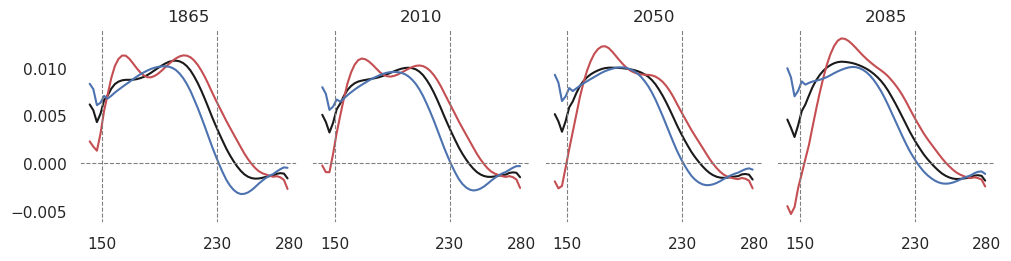

In [80]:
## specify months
MONTHS = [10,11,12]
# MONTHS = [1,2,3]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

    ## get data for year
    ax.set_title(y)
    mu_y = sel(mu).sel(year=y, method="nearest")

    ## select data
    for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

        ax.plot(mu.longitude, mu_y[n].mean("member"), c=color)

src.utils.set_lims(axs)
for ax in axs[1:]:
    ax.set_yticks([])

for ax in axs:
    ax.set_xticks([150, 230, 280])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    for t in [150, 230]:
        ax.axvline(t, **ax_kwargs)

plt.show()

#### Scatter plot

In [86]:
def get_taux_w(taux):
    """compute taux over west/central Pacific"""

    ## make sure latitude is in taux
    if "latitude" in taux.dims:
        taux_ = copy.deepcopy(taux)
    else:
        taux_ = taux.expand_dims("latitude")

    ## specify averaging range
    idx = dict(longitude=slice(150,230),latitude=slice(-5,5))

    ## compute
    return taux_.sel(idx).mean(["longitude","latitude"])


## add to dataarray
anom_["taux_w"] = src.utils.reconstruct_wrapper(
    anom[["taux","taux_comp"]], fn=get_taux_w,
)["taux"]

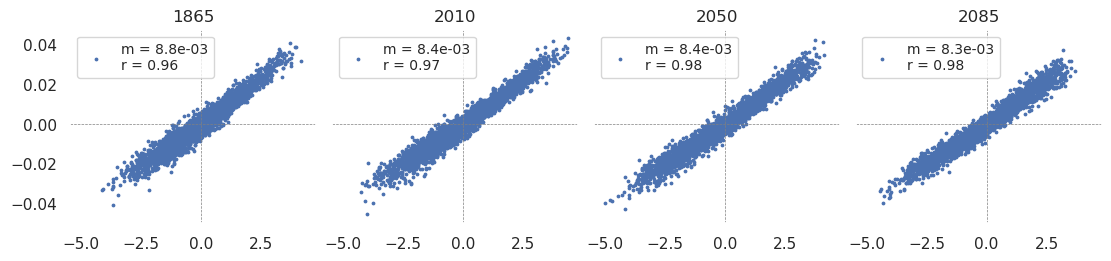

In [87]:
## specify kwargs
kwargs = dict(anom_=anom_, xvar="T_34", yvar="taux_w", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Timeseries

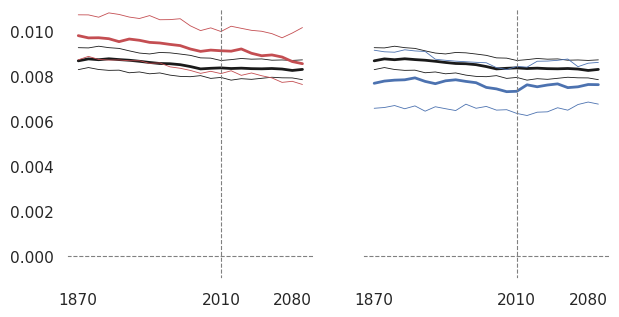

In [90]:
## extract R
sel = lambda x: get_taux_w(x).sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

## loop thru pos and negative
for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

    ## plot neutral and pos/or neg
    for name_, color_ in zip(["all", name], ["k", color]):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

            ## finally, plot data
            axs[i].plot(
                mu.year,
                sel(mu)[name_].quantile(q=q, dim="member"),
                c=color_,
                lw=lw,
            )

## formatting
# axs[0].set_yticks([0, 1, 2])
axs[1].set_yticks([])
src.utils.set_lims(axs)
for ax in axs:
    ax.set_xticks([1870, 2010, 2080])
    # ax.set_yticks([0,125,250])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.set_ylim([-1e-3,None])

plt.show()

### Sverdrup balance

In [52]:
def postprocess_ssh(coefs):
    """post-process regression coefficients"""

    ## reconstruct mean over equatorial region
    coefs_ = src.utils.reconstruct_wrapper(
        xr.merge([coefs, anom["ssh_comp"]]),
        fn=lambda x: x.sel(longitude=slice(120, 280), latitude=slice(-5, 5)).mean(
            "latitude"
        ),
    )

    ## drop extra variables
    mu = coefs_["ssh"].squeeze(drop=True)

    return mu

In [53]:
## get data for regression
anom_ = xr.merge([anom["ssh"], anom[["T_3", "T_34"]]])

## specify kwargs
regress_kwargs = dict(x_vars=["T_34"], y_vars=["ssh"], dims=DIMS)
regress_helper = lambda x: postprocess_ssh(regress_over_time(x, **regress_kwargs))

## do the regression
beta_all = regress_helper(anom_)
beta_pos = regress_helper(anom_.where(anom_["T_34"] > 0))
beta_neg = regress_helper(anom_.where(anom_["T_34"] < 0))

## merge into single dataarray
beta = xr.merge([beta_all.rename("all"), beta_pos.rename("pos"), beta_neg.rename("neg")])

100%|██████████| 23/23 [00:10<00:00,  2.16it/s]


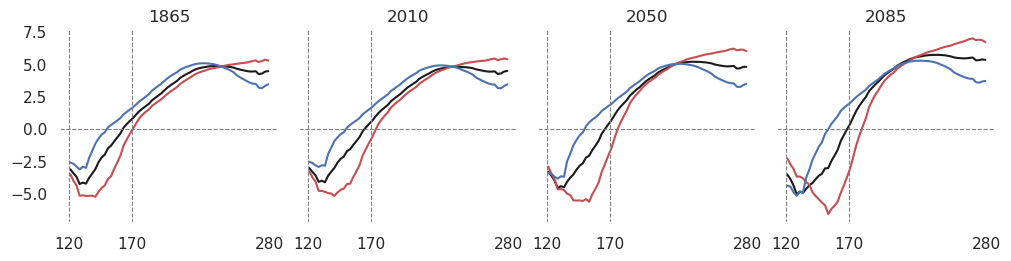

In [60]:
## specify months
MONTHS = [10,11,12]
# MONTHS = [1,2,3]

## sel
sel = lambda x: x.sel(month=MONTHS).mean("month")

fig, axs = plt.subplots(1, 4, figsize=(10, 2.5), layout="constrained")

for ax, y in zip(axs, [1865, 2010, 2050, 2085]):

    ## get data for year
    ax.set_title(y)
    beta_y = sel(beta).sel(year=y, method="nearest")

    ## select data
    for n, color in zip(["all", "pos", "neg"], ["k", "r", "b"]):

        ax.plot(beta.longitude, beta_y[n].mean("member"), c=color)

src.utils.set_lims(axs)
for ax in axs[1:]:
    ax.set_yticks([])

for ax in axs:
    ax.set_xticks([120, 170, 280])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    for t in [120, 170]:
        ax.axvline(t, **ax_kwargs)

plt.show()

In [67]:
def get_dh(ssh):
    """compute taux over west/central Pacific"""

    ## check if latitude is in ssh
    if "latitude" in ssh.dims:
        ssh_ = copy.deepcopy(ssh)
    else:
        ssh_ = ssh.expand_dims("latitude")

    ## specify averaging range
    idx_w = dict(longitude=slice(120,170),latitude=slice(-5,5))
    idx_e = dict(longitude=slice(170,280),latitude=slice(-5,5))

    ## get averages
    h_e = ssh_.sel(idx_e).mean("latitude").sum("longitude")
    h_w = ssh_.sel(idx_w).mean("latitude").sum("longitude")

    ## compute
    return h_e-h_w


## add to dataarray
anom_["dh"] = src.utils.reconstruct_wrapper(
    anom[["ssh","ssh_comp"]], fn=get_dh,
)["ssh"]

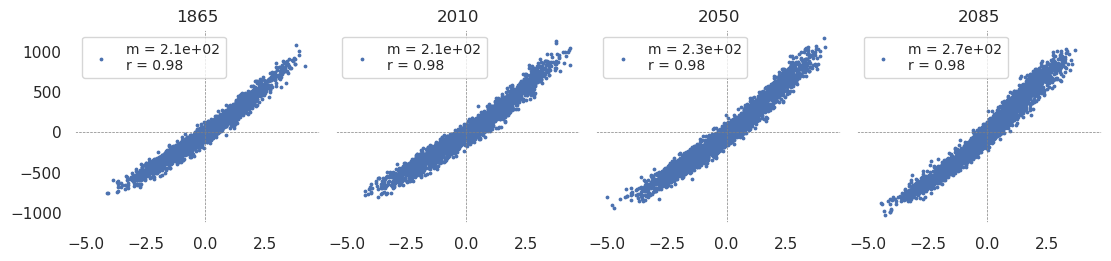

In [68]:
## specify kwargs
kwargs = dict(anom_=anom_, xvar="T_34", yvar="dh", month=10, by_season=True)

fig, axs = make_scatter(**kwargs)
plt.show()

#### Timeseries

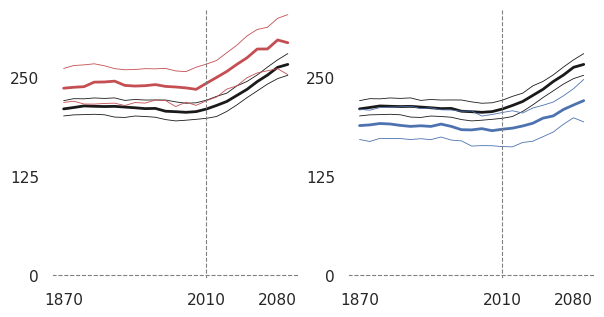

In [75]:
## extract R
sel = lambda x: get_dh(x).sel(month=slice(10, 12)).mean("month")

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

## loop thru pos and negative
for i, (name, color) in enumerate(zip(["pos", "neg"], ["r", "b"])):

    ## plot neutral and pos/or neg
    for name_, color_ in zip(["all", name], ["k", color]):

        ## plot median and bounds
        for q, lw in zip([0.5, 0.1, 0.9], [2, 0.6, 0.6]):

            ## finally, plot data
            axs[i].plot(
                beta.year,
                sel(beta)[name_].quantile(q=q, dim="member"),
                c=color_,
                lw=lw,
            )

## formatting
# axs[0].set_yticks([0, 1, 2])
axs[1].set_yticks([])
src.utils.set_lims(axs)
for ax in axs:
    ax.set_xticks([1870, 2010, 2080])
    ax.set_yticks([0,125,250])
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    ax.axvline(2010, **ax_kwargs)
    ax.axhline(0, **ax_kwargs)
    ax.set_ylim([-5,None])

plt.show()